In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  # *** 머지 ***


# ---------------------------------------
# 한글 폰트 설정 (OS 자동 감지)
# ---------------------------------------
import platform
_os = platform.system()
if _os == 'Windows':
    plt.rc('font', family='Malgun Gothic')     # 윈도우
elif _os == 'Darwin':
    plt.rc('font', family='AppleGothic')        # 맥
else:
    plt.rc('font', family='NanumGothic')        # 리눅스 / 구글 코랩
plt.rc('axes', unicode_minus=False)

In [33]:
import glob
import os


# 1. 상대 경로 설정 (현재 작업 폴더 내의 data 폴더)
folder_path = "./data"  # 또는 간단히 "data"

# 2. 해당 폴더의 모든 .csv 파일 경로 수집
file_list = glob.glob(os.path.join(folder_path, "*.csv"))

# 3. CSV 파일 일괄 읽기 (한글 깨짐 방지 cp949)
df_list = []
for file in file_list:
    temp_df = pd.read_csv(file, encoding="cp949")
    df_list.append(temp_df)

# 4. 하나의 데이터프레임으로 통합
df_src = pd.concat(df_list, ignore_index=True)
df_src.rename(
    columns={"전용면적(㎡)": "전용면적", "거래금액(만원)": "거래금액"},
    inplace=True,
)

df_src.info()
df_src.head(1)


<class 'pandas.DataFrame'>
RangeIndex: 219414 entries, 0 to 219413
Data columns (total 21 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   NO       219414 non-null  int64  
 1   시군구      219414 non-null  str    
 2   번지       219414 non-null  str    
 3   본번       219414 non-null  int64  
 4   부번       219414 non-null  int64  
 5   단지명      219414 non-null  str    
 6   전용면적     219414 non-null  float64
 7   계약년월     219414 non-null  int64  
 8   계약일      219414 non-null  int64  
 9   거래금액     219414 non-null  str    
 10  동        219414 non-null  str    
 11  층        219414 non-null  int64  
 12  매수자      219414 non-null  str    
 13  매도자      219414 non-null  str    
 14  건축년도     219414 non-null  int64  
 15  도로명      219414 non-null  str    
 16  해제사유발생일  219414 non-null  str    
 17  거래유형     219414 non-null  str    
 18  중개사소재지   219414 non-null  str    
 19  등기일자     219414 non-null  str    
 20  주택유형     83777 non-null   str    
dty

,NO,시군구,번지,본번,부번,단지명,전용면적,계약년월,계약일,거래금액,...,층,매수자,매도자,건축년도,도로명,해제사유발생일,거래유형,중개사소재지,등기일자,주택유형
0,1,서울특별시 중랑구 신내동,650,650,0,신내6대주,49.77,202312,31,"49,000",...,6,-,-,1996,신내로19길 42,-,중개거래,서울 중랑구,24.02.26,NaN


### 데이터 정제

In [34]:
df = df_src.copy()

# ----------------------------------------------------------------
# 1. 시군구 쪼개기
# ----------------------------------------------------------------
split_data = df['시군구'].str.split(' ', expand=True)

df['시'] = split_data[0]
df['구'] = split_data[1]
df['행정동'] = split_data[2]    # *** 머지 ***

# ----------------------------------------------------------------
# 2. 매수자/매도자/ㅇㅇㅇㅇ 컬럼 삭제
# ----------------------------------------------------------------
del df['매수자']
del df['매도자']
del df['중개사소재지']

# ----------------------------------------------------------------
# 3. 계약연월일 일자 합치기
# ----------------------------------------------------------------
# 계약일자와 계약년월을 str 형태로 이어붙여 표기
date_str = df['계약년월'].astype(str) + df['계약일'].astype(str)
df['계약일자'] = pd.to_datetime(date_str)
# 계약년월을 YYYYMM(int) -> YYYY-MM 형식으로 변환
df['계약년월'] = df['계약일자'].dt.to_period('M')
# 계약년도 추가 *** 머지 ***
df['계약년도'] = df['계약일자'].dt.year     # *** 머지 ***
# 계약년월 계약일 컬럼 삭제
df = df.drop(['계약일'], axis=1)

# ----------------------------------------------------------------
# 4. 전용면적을 평수로 전환하기
# ----------------------------------------------------------------
df['평수'] = (df['전용면적'] / 3.3058).round(1)

# ----------------------------------------------------------------
# 5. 거래금액을 int형으로 전환
# ----------------------------------------------------------------
df['거래금액'] = df['거래금액'].str.replace(',', '').astype(int)

# ----------------------------------------------------------------
# 6. 해제가 있는 행은 취소컬럼 생성
# ----------------------------------------------------------------
# 해제사유발생일 Nan 처리 및 dateTime 처리
df['해제사유발생일'] = df['해제사유발생일'].replace('-', np.nan)
df['해제사유발생일'] = pd.to_datetime(df['해제사유발생일'])
# 해제 사유 발생일 존재 시 '해제' 컬럼에 True False 표시
df['취소'] = df['해제사유발생일'].notna()

# ----------------------------------------------------------------
# 7. 등기여부 컬럼 추가, True / False 후 True만 집계 포함
# ----------------------------------------------------------------
# 등기일자 Nan 처리 및 dateTime 처리
df['등기일자'] = df['등기일자'].replace('-', np.nan)
df['등기일자'] = pd.to_datetime(df['등기일자'], format='%y.%m.%d', errors="coerce")

## 등기여부 라는 컬럼을 표시하고 True False 로 하고 True 인 애들만 집계에 포함하기 - 종호
# '등기일자'가 NaT가 아니면(값이 있으면) True, NaT이면 False
df["등기여부"] = df["등기일자"].notna()

# 결과 확인
df.info()
df.head(1)
# # 등기여부가 False인 행들만 표로 보기
# true_df = df[df["등기여부"] == True]

# # 상위 5개 출력
# true_df.head()

<class 'pandas.DataFrame'>
RangeIndex: 219414 entries, 0 to 219413
Data columns (total 25 columns):
 #   Column   Non-Null Count   Dtype         
---  ------   --------------   -----         
 0   NO       219414 non-null  int64         
 1   시군구      219414 non-null  str           
 2   번지       219414 non-null  str           
 3   본번       219414 non-null  int64         
 4   부번       219414 non-null  int64         
 5   단지명      219414 non-null  str           
 6   전용면적     219414 non-null  float64       
 7   계약년월     219414 non-null  period[M]     
 8   거래금액     219414 non-null  int64         
 9   동        219414 non-null  str           
 10  층        219414 non-null  int64         
 11  건축년도     219414 non-null  int64         
 12  도로명      219414 non-null  str           
 13  해제사유발생일  11615 non-null   datetime64[us]
 14  거래유형     219414 non-null  str           
 15  등기일자     189066 non-null  datetime64[us]
 16  주택유형     83777 non-null   str           
 17  시        219414 non-n

,NO,시군구,번지,본번,부번,단지명,전용면적,계약년월,거래금액,동,...,등기일자,주택유형,시,구,행정동,계약일자,계약년도,평수,취소,등기여부
0,1,서울특별시 중랑구 신내동,650,650,0,신내6대주,49.77,2023-12,49000,608,...,2024-02-26,NaN,서울특별시,중랑구,신내동,2023-12-31,2023,15.1,False,True


### 김병수

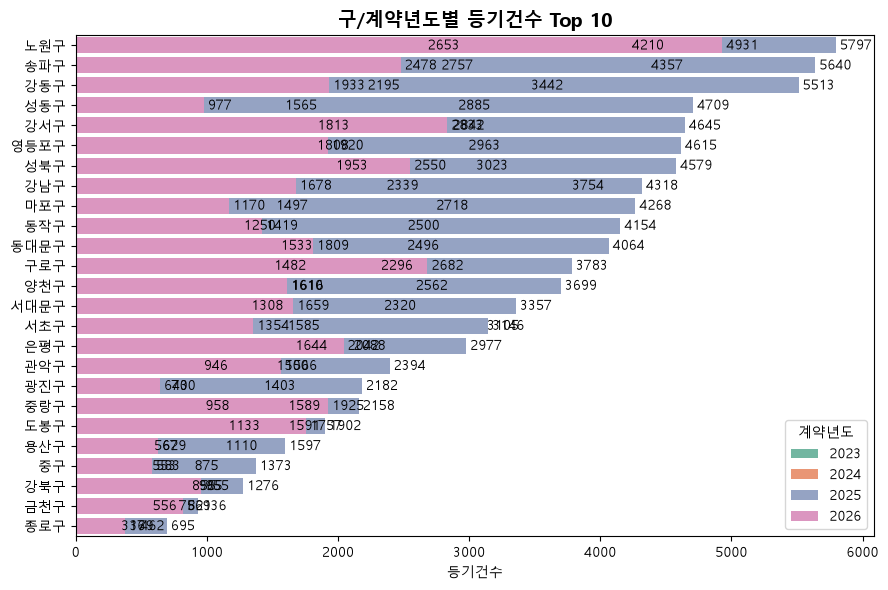

In [35]:
# (BS)
# 최근 4년동안 단지명을 기준으로 총거래건수 합을 구한다.

# 구 단위로 거래량 추출
txAmt_gu = df.groupby(['구', '계약년도'])['등기여부'].count().sort_values(ascending=False).to_frame()
# dfTxAmt.to_frame()
txAmt_gu.rename(columns={"등기여부": "거래건수"}, inplace=True)
txAmt_gu

plt.figure(figsize=(9, 6))
ax = sns.barplot(data=txAmt_gu, x='거래건수', y='구', hue='계약년도', dodge=False, palette='Set2')
# 막대 끝에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('구/계약년도별 등기건수 Top 10', fontsize=14, fontweight='bold')
plt.xlabel('등기건수')
plt.ylabel('')
plt.legend(title='계약년도')
plt.tight_layout()

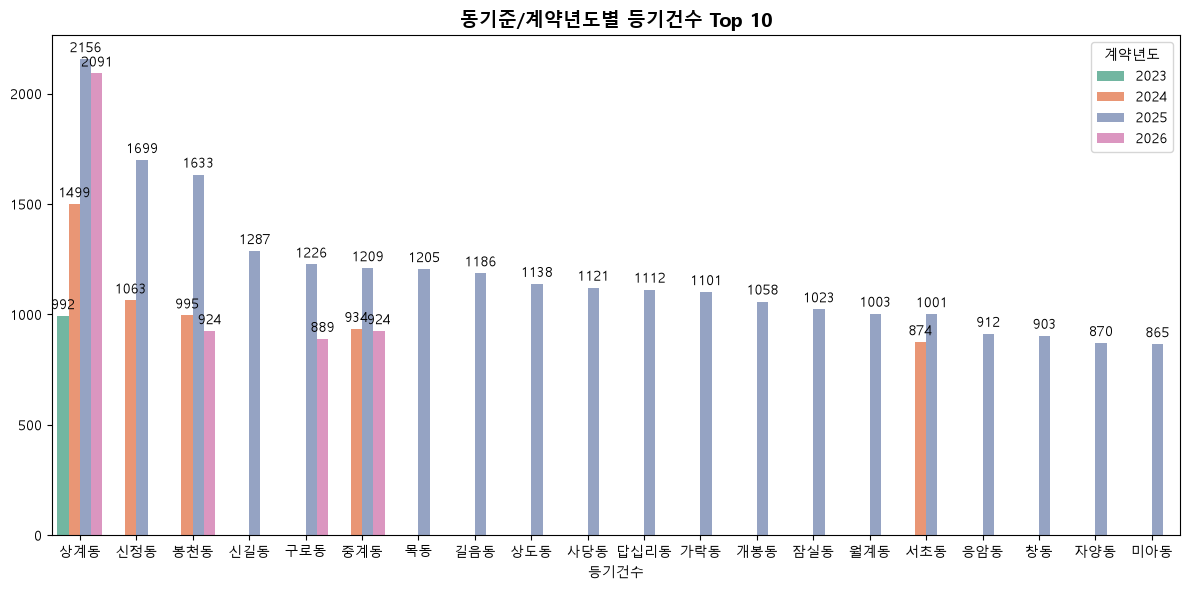

In [36]:
# (BS)
# 최근 4년동안 행정동 기준 상위 30개  

# 구 단위로 거래량 추출
txAmt_Dong = df.groupby(['구', '행정동', '계약년도'])['등기여부'].count().sort_values(ascending=False).to_frame()
# dfTxAmt.to_frame()
txAmt_Dong.rename(columns={"등기여부": "거래건수"}, inplace=True)
txAmt_Dong_top30 = txAmt_Dong.head(30)
txAmt_Dong_top30

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=txAmt_Dong_top30, x='행정동', y='거래건수', hue='계약년도', palette='Set2')
# 막대 끝에 값 표시
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=3)

plt.title('동기준/계약년도별 등기건수 Top 10', fontsize=14, fontweight='bold')
plt.xlabel('등기건수')
plt.ylabel('')
plt.legend(title='계약년도')
plt.tight_layout()

C:\Users\user\AppData\Local\Temp\ipykernel_24844\3946968496.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=trx_apt_30, x='단지명', y='등기여부', palette='Set2')


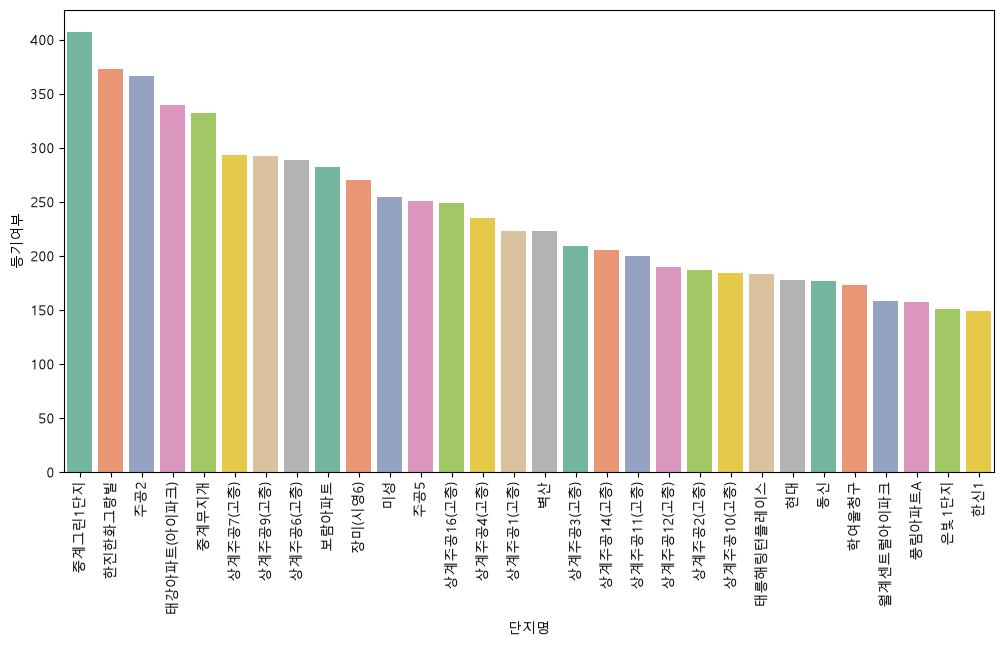

In [37]:
# (BS)
# 최근 4년동안 상계동에서 가장 거래 많은 상위 단지  

cond = df['구'] == '노원구'
nowon = df.loc[cond, :]
trx_apt = nowon.groupby(['단지명'])['등기여부'].sum().sort_values(ascending=False).to_frame()
trx_apt_30 = trx_apt.head(30)

plt.figure(figsize=(12, 6))
# ax = sns.barplot(data=trx_apt, x='단지명', y='등기여부', hue='계약년도', palette='Set2')
ax = sns.barplot(data=trx_apt_30, x='단지명', y='등기여부', palette='Set2')
plt.xticks(rotation=90);


### 김종호

C:\Users\user\AppData\Local\Temp\ipykernel_24844\2446968385.py:86: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_24844\2446968385.py:86: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\miniconda3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniconda3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


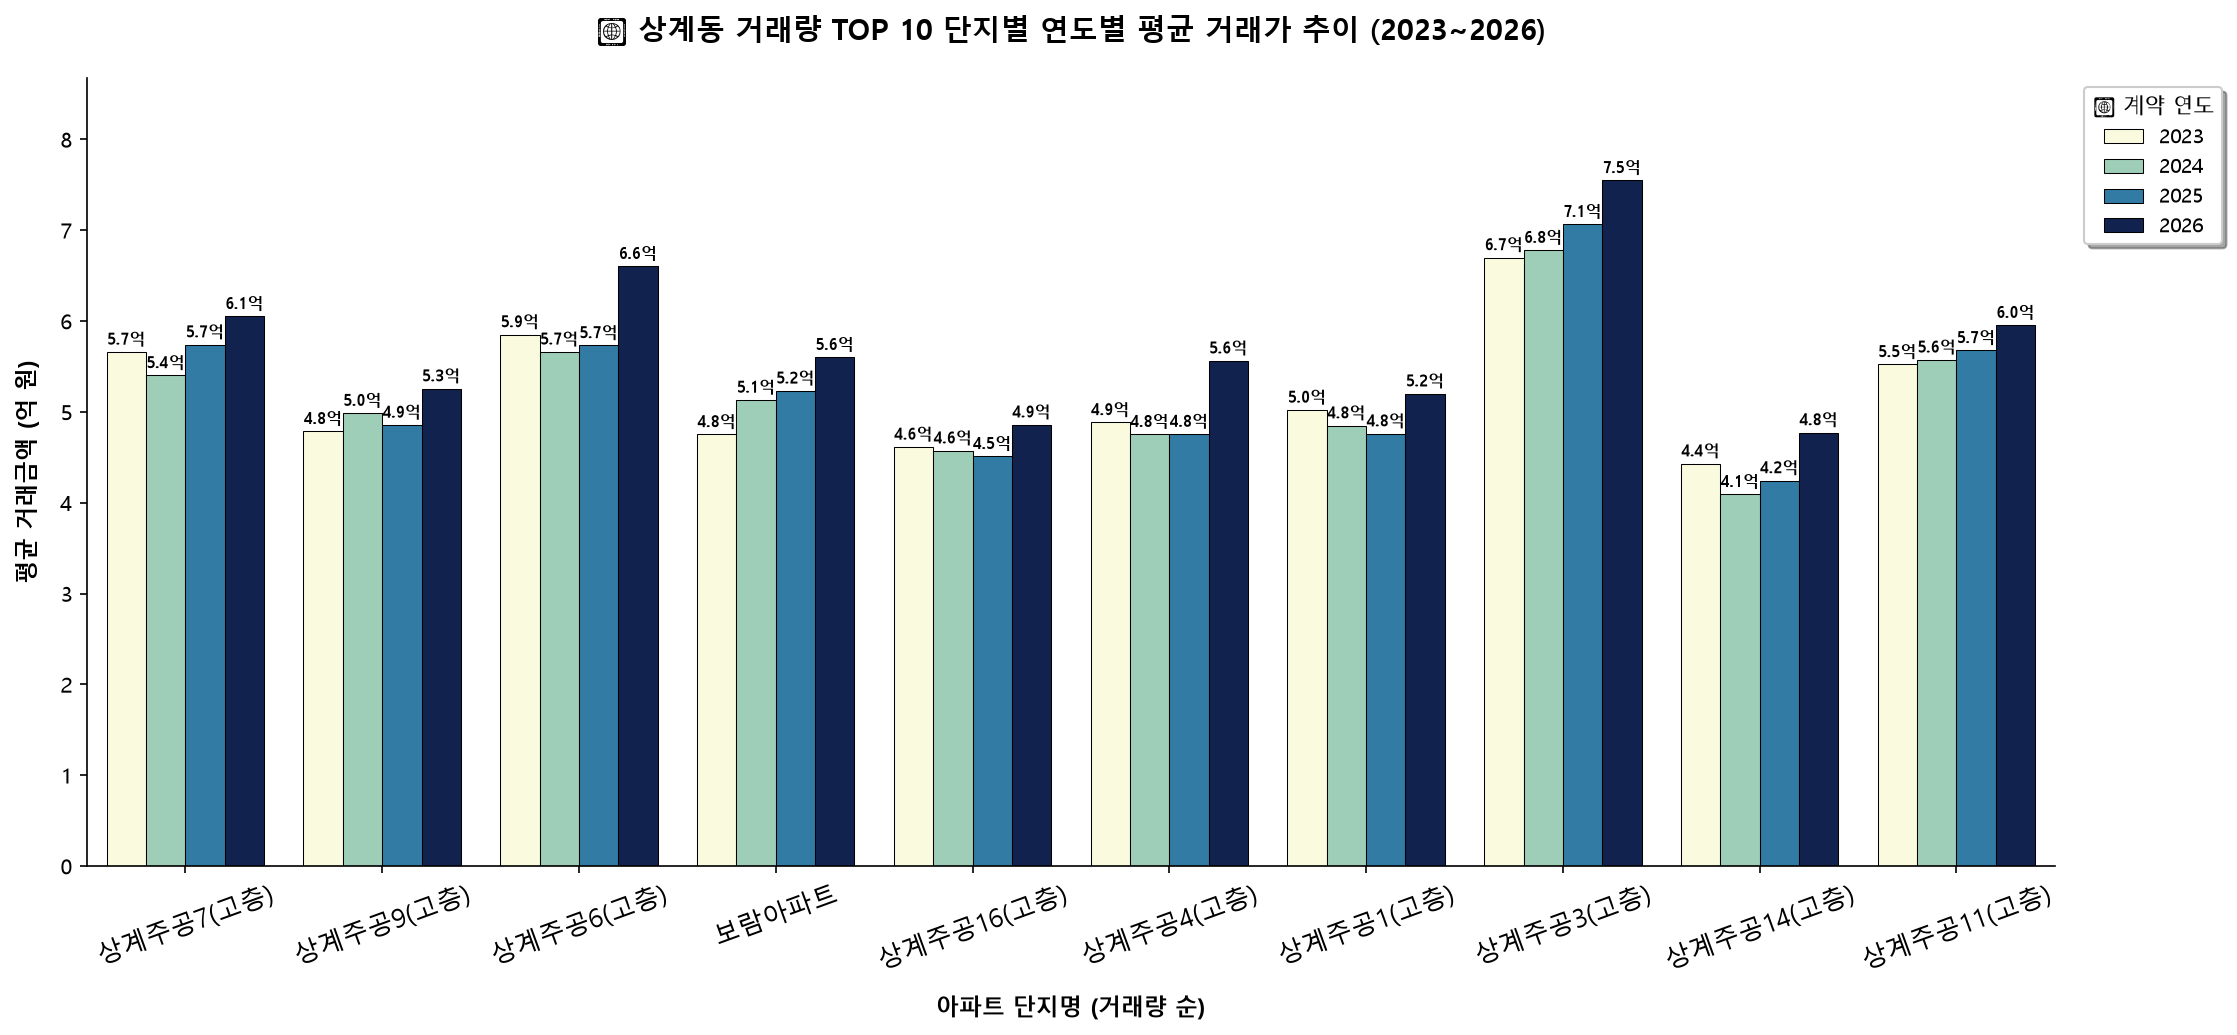

In [ ]:
# 2. 상계동 데이터 필터링 및 연도 추출
sanggye_df = true_df[true_df["시군구"].str.contains("상계동", na=False)].copy()
sanggye_df["연도"] = sanggye_df["계약년월"].astype(str).str[:4].astype(int)

# 2023년~2026년 필터링 및 억 원 단위 변환
sanggye_df = sanggye_df[
    (sanggye_df["연도"] >= 2023) & (sanggye_df["연도"] <= 2026)
]
sanggye_df["거래금액_억원"] = sanggye_df["거래금액"] / 10000

# 3. 거래량 상위 TOP 10 단지 추출 및 정렬 (거래량 순으로 유지)
top10_complexes = sanggye_df["단지명"].value_counts().head(10).index
filtered_sanggye = sanggye_df[sanggye_df["단지명"].isin(top10_complexes)]

# 단지별, 연도별 평균 거래금액 집계
complex_yearly = (
    filtered_sanggye.groupby(["단지명", "연도"])["거래금액_억원"]
    .mean()
    .reset_index()
)

# 4. Barplot 생성 (단지수가 많으므로 가로 폭을 늘림)
fig, ax = plt.subplots(figsize=(15, 7), dpi=150)

# X축: 단지명, Hue: 연도 (단지별 연도 추이를 모아보기 용이)
bar_plot = sns.barplot(
    data=complex_yearly,
    x="단지명",
    y="거래금액_억원",
    hue="연도",
    order=top10_complexes,  # 거래량이 많은 순서대로 X축 정렬
    palette="YlGnBu",  # 연도가 진행될수록 짙어지는 색상 테마
    ax=ax,
    edgecolor="black",
    linewidth=0.5,
)

# 5. 막대 위에 금액 수치(값) 표기
for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(
            f"{height:.1f}억",  # 공간 확보를 위해 소수점 첫째 자리까지 표기
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=7.5,
            fontweight="bold",
            xytext=(0, 2),
            textcoords="offset points",
            rotation=0,
        )

# 6. 차트 디테일 설정
ax.set_title(
    "📊 상계동 거래량 TOP 10 단지별 연도별 평균 거래가 추이 (2023~2026)",
    fontsize=14,
    fontweight="bold",
    pad=18,
)
ax.set_xlabel("아파트 단지명 (거래량 순)", fontsize=11, fontweight="bold", labelpad=10)
ax.set_ylabel(
    "평균 거래금액 (억 원)", fontsize=11, fontweight="bold", labelpad=10
)

# X축 단지명 라벨 회전 (긴 이름 겹침 방지)
plt.xticks(rotation=20, fontsize=12.5)

# Y축 범위 설정
max_val = complex_yearly["거래금액_억원"].max()
ax.set_ylim(0, max_val * 1.15)

# 범례(Legend) 스타일링
ax.legend(
    title="📅 계약 연도",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
    fontsize=9.5,
    title_fontsize=10,
)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_24844\3617047455.py:93: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_24844\3617047455.py:93: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  plt.tight_layout()
c:\Users\user\miniconda3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\user\miniconda3\envs\data\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128197 (\N{CALENDAR}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


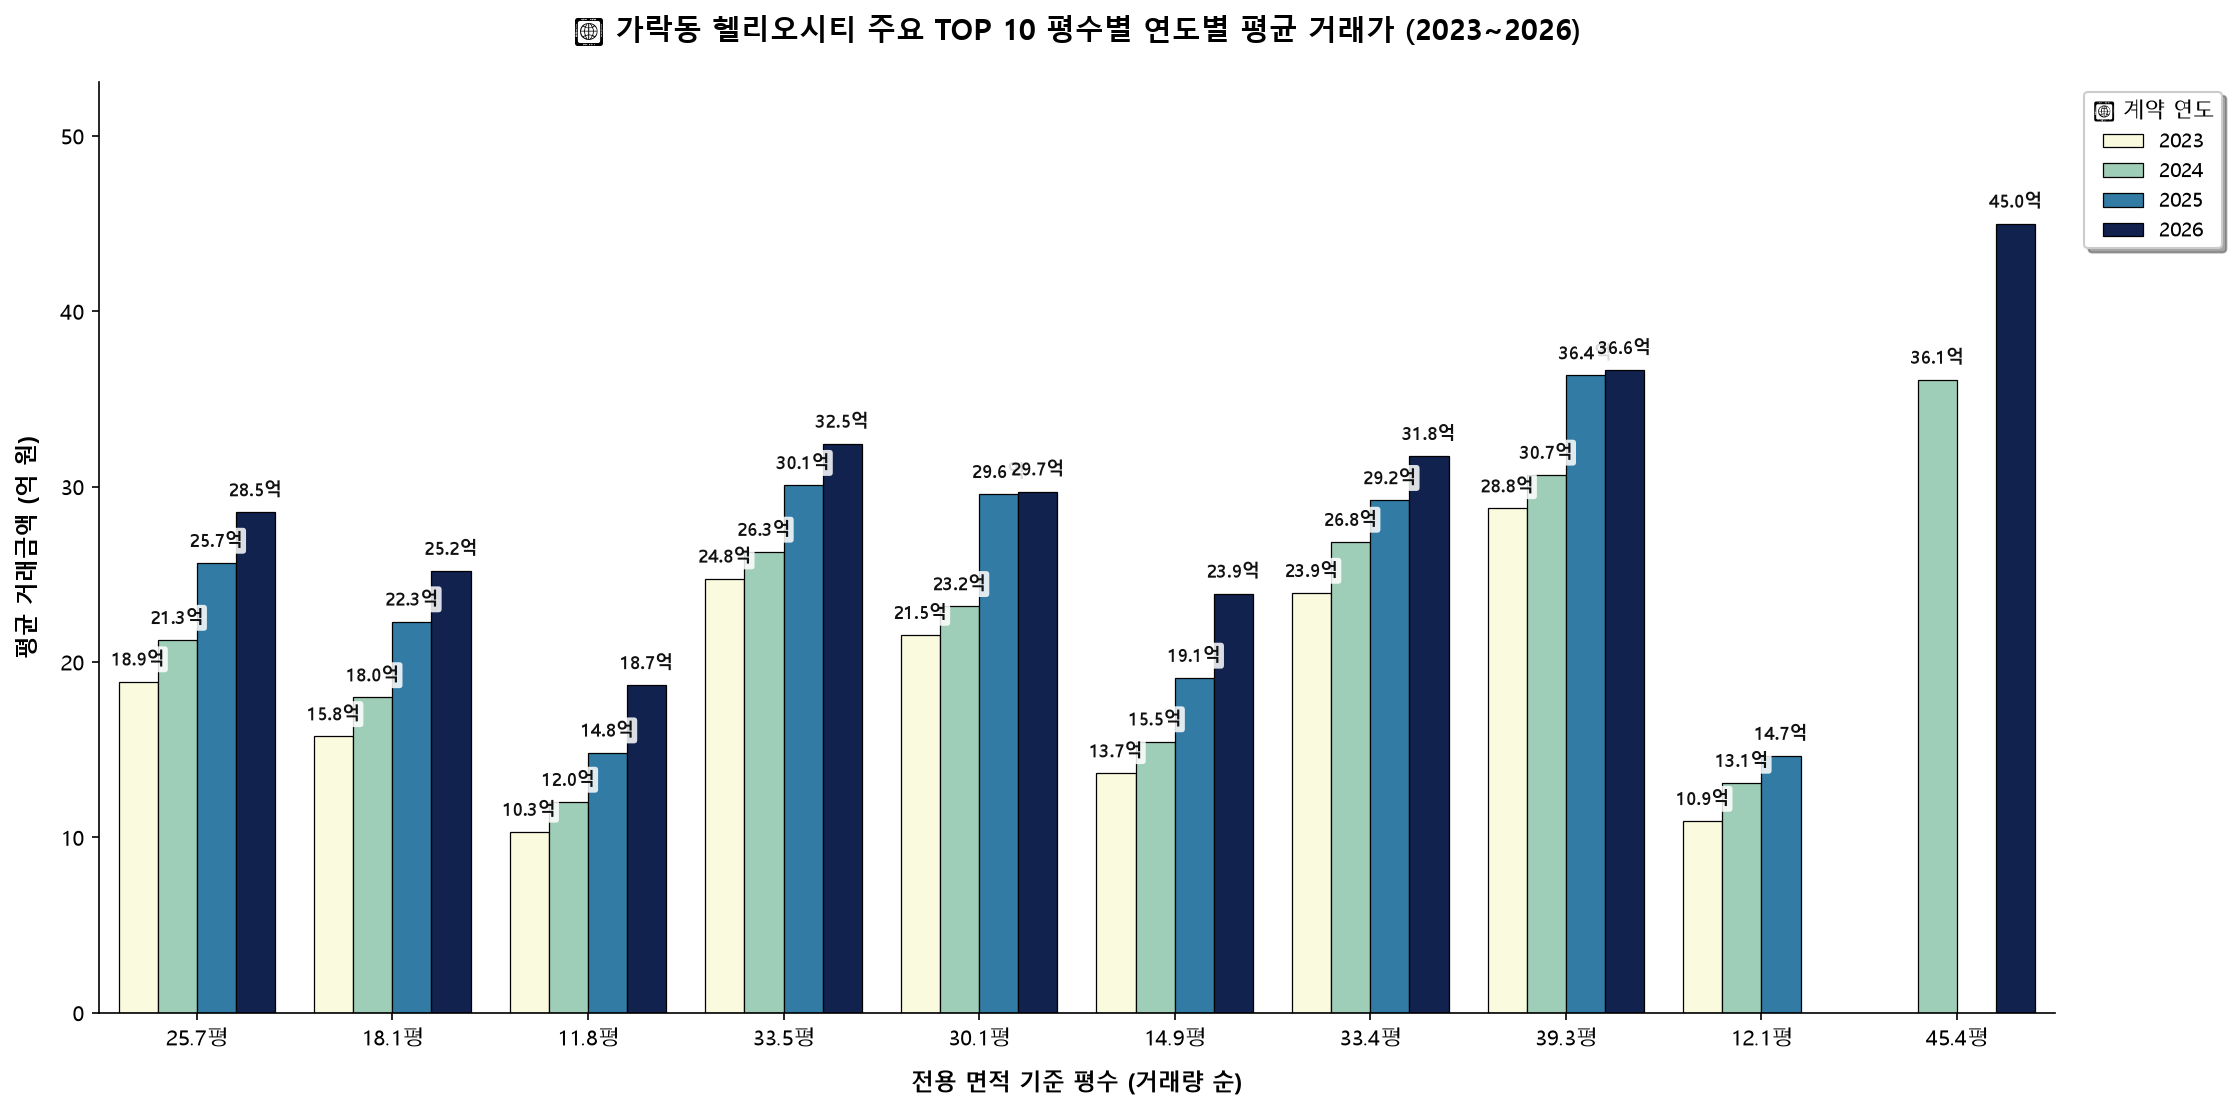

In [39]:
# 연도별 가락동 평수당 평균거래금액
helio_df = true_df[
    (true_df["시군구"].str.contains("가락동", na=False))
    & (true_df["단지명"].str.contains("헬리오시티", na=False))
].copy()

helio_df["연도"] = helio_df["계약년월"].astype(str).str[:4].astype(int)
helio_df = helio_df[(helio_df["연도"] >= 2023) & (helio_df["연도"] <= 2026)]
helio_df["거래금액_억원"] = helio_df["거래금액"] / 10000

if "평수" not in helio_df.columns:
    helio_df["평수"] = (helio_df["전용면적"] / 3.30578).round(1)

helio_df["평수_라벨"] = helio_df["평수"].astype(str) + "평"

top10_pyeong_labels = helio_df["평수_라벨"].value_counts().head(10).index
filtered_helio = helio_df[helio_df["평수_라벨"].isin(top10_pyeong_labels)]

pyeong_yearly = (
    filtered_helio.groupby(["평수_라벨", "연도"])["거래금액_억원"]
    .mean()
    .reset_index()
)

# 3. Barplot 생성
fig, ax = plt.subplots(figsize=(15, 7.5), dpi=150)

bar_plot = sns.barplot(
    data=pyeong_yearly,
    x="평수_라벨",
    y="거래금액_억원",
    hue="연도",
    order=top10_pyeong_labels,
    palette="YlGnBu",
    ax=ax,
    edgecolor="black",
    linewidth=0.6,
)

# 4. 🔥 [핵심] 수치 텍스트 가독성 최적화
for p in bar_plot.patches:
    height = p.get_height()
    if not pd.isna(height) and height > 0:
        ax.annotate(
            f"{height:.1f}억",
            (p.get_x() + p.get_width() / 2.0, height),
            ha="center",
            va="bottom",
            fontsize=8.5,  # 폰트 크기 확대
            fontweight="bold",  # 굵은 글씨
            color="#111111",  # 명확한 검은색 계열
            xytext=(0, 6),  # 막대 끝에서 6pt 위로 띄움
            textcoords="offset points",
            bbox=dict(
                boxstyle="round,pad=0.18",
                facecolor="white",  # 흰색 배경 박스
                edgecolor="none",  # 박스 테두리 없음
                alpha=0.85,  # 약간의 투명도 주어 자연스럽게 매칭
            ),
        )

# 5. 레이아웃 디테일 설정
ax.set_title(
    "📊 가락동 헬리오시티 주요 TOP 10 평수별 연도별 평균 거래가 (2023~2026)",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel(
    "전용 면적 기준 평수 (거래량 순)", fontsize=11, fontweight="bold", labelpad=10
)
ax.set_ylabel(
    "평균 거래금액 (억 원)", fontsize=11, fontweight="bold", labelpad=10
)

# Y축 여유 공간 확보 (숫자 텍스트 박스가 잘리지 않도록 1.18 배 설정)
max_val = pyeong_yearly["거래금액_억원"].max()
ax.set_ylim(0, max_val * 1.18)

# 범례(Legend) 설정
ax.legend(
    title="📅 계약 연도",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    frameon=True,
    shadow=True,
    fontsize=9.5,
    title_fontsize=10,
)

sns.despine(top=True, right=True)

plt.tight_layout()
plt.show()

### 정해찬

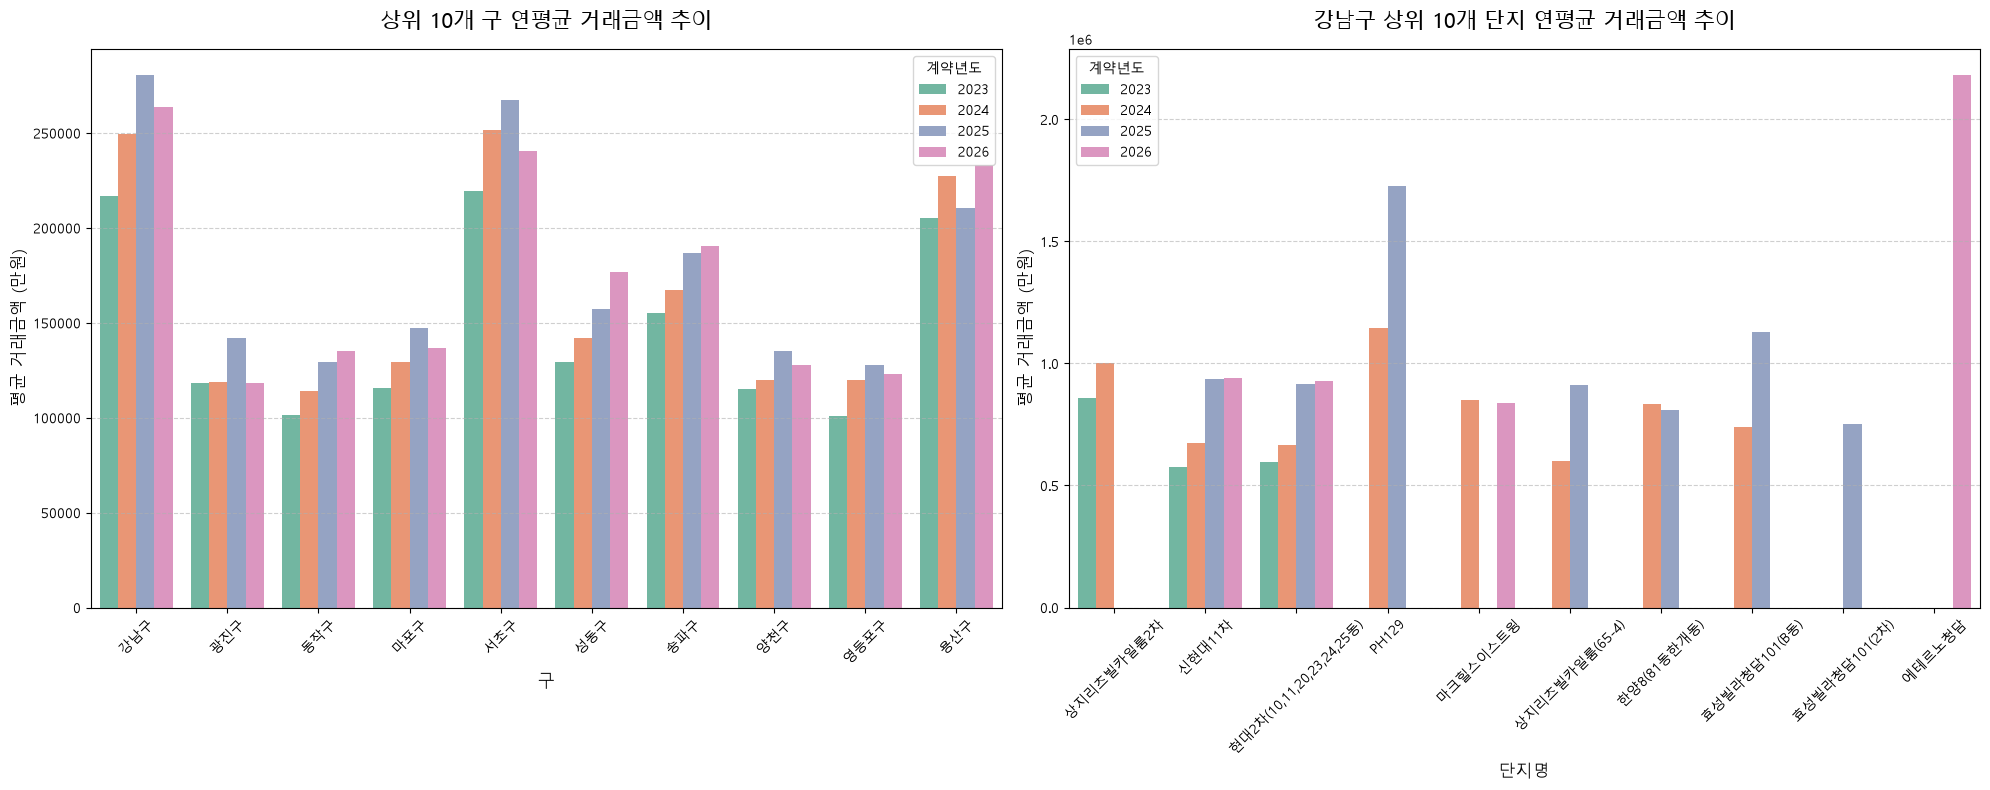

In [40]:
# 1. 공통 전처리

true_df = df[(df['취소'] == False) & (df['등기여부'] == True)].copy()
true_df = true_df[true_df['계약일자'] >= '2020-01-01']
# hue에 들어갈 이름을 직관적으로 맞추기 위해 '계약년도'로 지정
true_df['계약년도'] = true_df['계약일자'].dt.year


# 2. 상위 10개 구

top10_gu = true_df.groupby('구')['거래금액'].mean().nlargest(10).index.tolist()


gu_bar_df = true_df[true_df['구'].isin(top10_gu)].groupby(['계약년도', '구'])['거래금액'].mean().reset_index().round(0)


# 3. 강남구 내 상위 10개 단지명

gangnam_df = true_df[true_df['구'] == '강남구']

top10_danji = gangnam_df.groupby('단지명')['거래금액'].mean().nlargest(10).index.tolist()

danji_bar_df = gangnam_df[gangnam_df['단지명'].isin(top10_danji)].groupby(['계약년도', '단지명'])['거래금액'].mean().reset_index().round(0)


# 4. 그래프


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# 상위 10개 구
sns.barplot(data=gu_bar_df, x='구', y='거래금액', hue='계약년도', palette='Set2', ax=axes[0])
axes[0].set_title('상위 10개 구 연평균 거래금액 추이', fontsize=15, pad=15)
axes[0].set_xlabel('구', fontsize=12)
axes[0].set_ylabel('평균 거래금액 (만원)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# 강남구 상위 10개 단지
sns.barplot(data=danji_bar_df, x='단지명', y='거래금액', hue='계약년도', palette='Set2', ax=axes[1])
axes[1].set_title('강남구 상위 10개 단지 연평균 거래금액 추이', fontsize=15, pad=15)
axes[1].set_xlabel('단지명', fontsize=12)
axes[1].set_ylabel('평균 거래금액 (만원)', fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

### 이현경

In [41]:
# 시 컬럼에서 이상치 있나 확인 >> 없음
df['시'].unique()

# 구 컬럼 내 종류 확인 >> 25가지
df['구'].unique()

# 동 컬럼 내 종류 확인 >> 331가지
df['동'].unique()

# --------------------------
# 동 의 종류가 많아 분석방향 수정 : 거래금액 상승량이 가장 많은 '구' 상위 5개 선정
# --------------------------

# pivot_table 생성
# 계약년월이 시간순으로 나열된 index + 구 이름이 나열된 column
# values 는 거래금액의 총 합
gu_monthly_amount = df.pivot_table(index='계약년월', columns='구', values='거래금액', aggfunc='sum')
gu_monthly_amount.head()

구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
계약년월,,,,,,,,,,,,,,,,,,,,,
2023-01,18806100,12609200,1800000,4119000,1926350,3604500,2765200,1026500,7911520,3499550,...,5171300,6575900,24099950,6029900,5192550,2474100,3713926,734560,1627750,2412550
2023-02,34480120,20882280,2175970,11853790,3840300,5001900,5812840,2187000,11235300,5329600,...,9807250,10496100,38321060,11349100,9311870,4007198,6480018,2114000,4082300,3505350
2023-03,38838500,17516950,4244470,10946550,4517800,5783100,8538900,3391000,11185210,4498050,...,14188600,11496097,35468350,11832400,13562312,7753100,21937210,3056990,2995890,3899600
2023-04,45332210,24133893,3236850,13046410,5924450,8337100,9750930,3430850,12727620,4325900,...,16334980,12764550,43363695,14313130,16031857,8907098,11293800,2024600,3934100,5514100
2023-05,57050540,22273650,3471600,13664300,7724480,7852700,8548850,2660750,14336150,4776684,...,19716150,13589010,45982900,16490200,21524622,9263500,9729988,3301350,5145700,4187200


In [42]:
# rolling 데이터프레임 생성
# 3개월 기준으로 해보자

gu_monthly_amount_rolling = gu_monthly_amount.rolling(3, min_periods=3).mean().round()
gu_monthly_amount_rolling.head()

구,강남구,강동구,강북구,강서구,관악구,광진구,구로구,금천구,노원구,도봉구,...,성동구,성북구,송파구,양천구,영등포구,용산구,은평구,종로구,중구,중랑구
계약년월,,,,,,,,,,,,,,,,,,,,,
2023-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-03,30708240.0,17002810.0,2740147.0,8973113.0,3428150.0,4796500.0,5705647.0,2201500.0,10110677.0,4442400.0,...,9722383.0,9522699.0,32629787.0,9737133.0,9355577.0,4744799.0,10710385.0,1968517.0,2901980.0,3272500.0
2023-04,39550277.0,20844374.0,3219097.0,11948917.0,4760850.0,6374033.0,8034223.0,3002950.0,11716043.0,4717850.0,...,13443610.0,11585582.0,39051035.0,12498210.0,12968680.0,6889132.0,13237009.0,2398530.0,3670763.0,4306350.0
2023-05,47073750.0,21308164.0,3650973.0,12552420.0,6055577.0,7324300.0,8946227.0,3160867.0,12749660.0,4533545.0,...,16746577.0,12616552.0,41604982.0,14211910.0,17039597.0,8641233.0,14320333.0,2794313.0,4025230.0,4533633.0


,계약년월,구,3달거래금액평균
0,2023-01,강남구,NaN
1,2023-02,강남구,NaN
2,2023-03,강남구,30708240.0
3,2023-04,강남구,39550277.0
4,2023-05,강남구,47073750.0
...,...,...,...
1070,2026-03,중랑구,14831620.0
1071,2026-04,중랑구,19376880.0
1072,2026-05,중랑구,21773830.0
1073,2026-06,중랑구,21066913.0


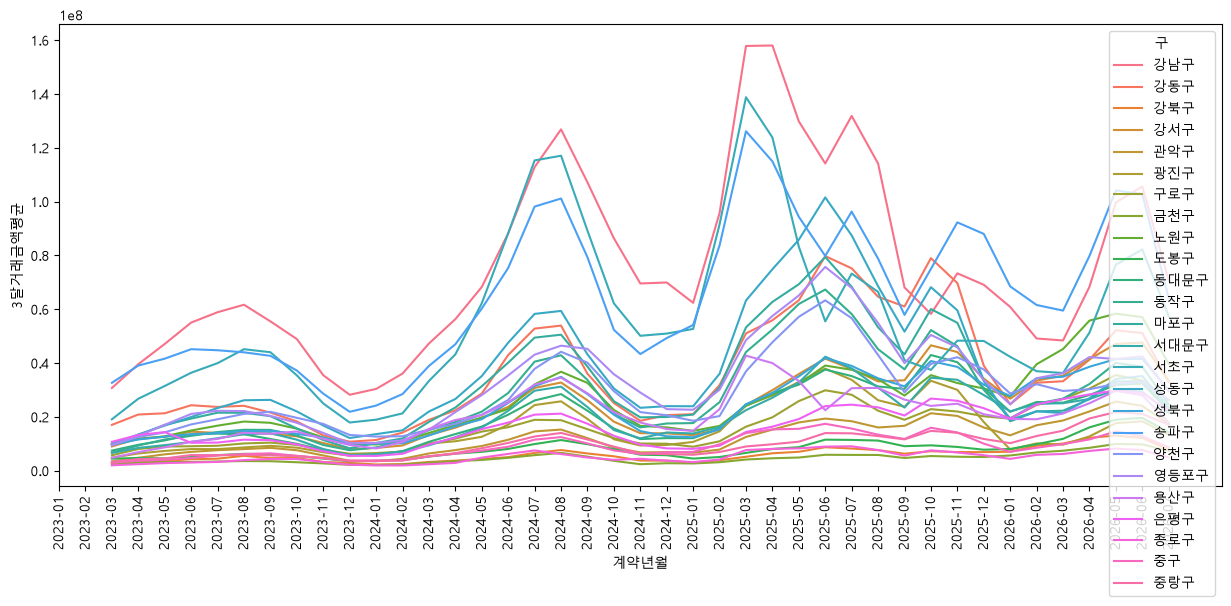

In [43]:
import seaborn as sns

#   id_vars    : 그대로 둘 기준 열  → '계약년월'
#   var_name   : 열 이름들이 담길 새 컬럼명  → '구'
#   value_name : 실제 값이 담길 새 컬럼명    → '거래금액'
# sns 의 hue 로 구를 구분하기 위해 melt 하기
gu_monthly_rolling_long = gu_monthly_amount_rolling.reset_index().melt(
    id_vars='계약년월', var_name='구', value_name='3달거래금액평균'
)

# 계약년월 type 이 이상해서 바꿔줌
gu_monthly_rolling_long['계약년월'] = gu_monthly_rolling_long['계약년월'].dt.strftime('%Y-%m')
type(gu_monthly_rolling_long['계약년월'].values)

display(gu_monthly_rolling_long)

plt.figure(figsize=(15,6))
sns.lineplot(gu_monthly_rolling_long, x = '계약년월', y = '3달거래금액평균', hue = '구')
plt.xticks(rotation = 90)
pass

# 너무 정신없어서 상위 5개 구만 뽑아보도록 하겠다

,계약년월,구,3달거래금액평균
0,2023-01,강남구,NaN
1,2023-02,강남구,NaN
2,2023-03,강남구,30708240.0
3,2023-04,강남구,39550277.0
4,2023-05,강남구,47073750.0
...,...,...,...
769,2026-03,송파구,59467815.0
770,2026-04,송파구,79775015.0
771,2026-05,송파구,104125522.0
772,2026-06,송파구,102780002.0


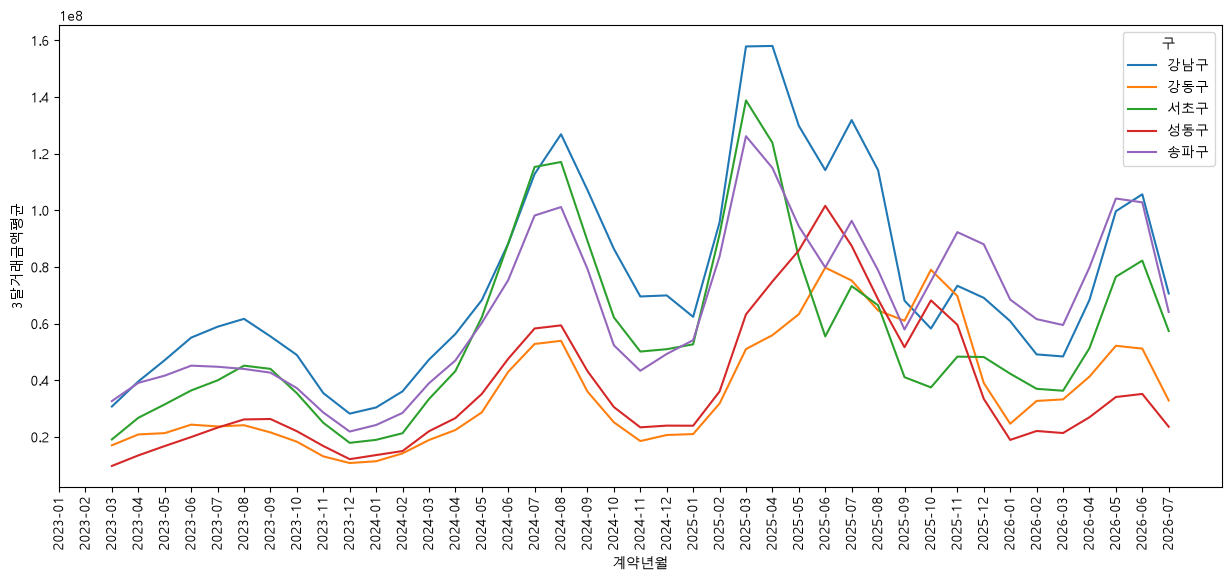

In [44]:
gu_monthly_rolling_long.sort_values(by='3달거래금액평균', ascending=False)
# 상위에 강남구 서초구만 떠서 groupby 해봄

gu_amount_mean = gu_monthly_rolling_long.groupby('구')['3달거래금액평균'].mean().to_frame()
# 강남구, 송파구, 서초구, 성동구, 강동구 로 선정되었다

gu_amount_mean.sort_values(by = '3달거래금액평균', ascending=False)

target_gu = ['강남구', '송파구', '서초구', '성동구', '강동구']
gu_monthly_upper5 = gu_monthly_rolling_long[gu_monthly_rolling_long['구'].isin(target_gu)]
display(gu_monthly_upper5)

plt.figure(figsize=(15,6))
sns.lineplot(gu_monthly_upper5, x = '계약년월', y = '3달거래금액평균', hue = '구')
plt.xticks(rotation = 90)
pass